In [1]:
# imports

import os
import os.path
import cv2
import glob
import h5py
import tqdm
import argparse
import logging
from PIL import Image 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
sns.set_theme()
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms

import sys
sys.path.append('../')
import data, utils, models

In [2]:
# # EXAMPLE NUMBER
# example = 0 # Set 1 for another example

In [3]:
# necessary variable deifnitons

parallel = True
Fast = False
pretrained = True
old = True
load_opt = False

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
transform = transforms.Compose([transforms.ToPILImage()])
to_gray = transforms.Compose([transforms.ToPILImage(), transforms.Grayscale(num_output_channels=1)])
center = transforms.Compose([transforms.CenterCrop(40)])

dataset = "Nanoparticles"
# video = f"frame_00_{example+1}"
patch_size = 128
stride = 128
is_image = False
n_frames = 5
cpf = 1
mid = n_frames // 2
is_real = True

aug = 0

# dist = 'G'
# mode = 'S'
# noise_std = 30
# min_noise = 0
# max_noise = 100

batch_size = 1
lr = 1e-4

In [4]:
# load model

PATH = "../experiments/blind-video-net-4/mse/checkpoints/checkpoint_best.pt"

model, optimizer, args = utils.load_model(PATH, parallel=parallel, pretrained=pretrained, old=old, load_opt=load_opt)
model.to(device)
print(model)

BlindVideoNet(
  (rotate): rotate()
  (denoiser_1): Blind_UNet(
    (enc1): ENC_Conv(
      (conv1): Conv(
        (shift_down): ZeroPad2d(padding=(0, 0, 1, 0), value=0.0)
        (crop): crop()
        (replicate): ReplicationPad2d((1, 1, 1, 1))
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), bias=False)
        (relu): LeakyReLU(negative_slope=0.1, inplace=True)
      )
      (conv2): Conv(
        (shift_down): ZeroPad2d(padding=(0, 0, 1, 0), value=0.0)
        (crop): crop()
        (replicate): ReplicationPad2d((1, 1, 1, 1))
        (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), bias=False)
        (relu): LeakyReLU(negative_slope=0.1, inplace=True)
      )
      (conv3): Conv(
        (shift_down): ZeroPad2d(padding=(0, 0, 1, 0), value=0.0)
        (crop): crop()
        (replicate): ReplicationPad2d((1, 1, 1, 1))
        (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), bias=False)
        (relu): LeakyReLU(negative_slope=0.1, inplace=True)
  

In [24]:
# data loader

PATH = "../dataset_SI//"
train_loader, test_loader = data.build_dataset("Nanoparticles", PATH, batch_size=1, image_size=128, 
                                               stride = 128, n_frames = 5, aug = 0)

In [25]:
C,H,W = test_loader.dataset[0].shape

In [26]:
print(C,H,W)

15 256 499


# 调试内容

In [27]:
# train_dataset = data.Nanoparticles(PATH, datatype="train", patch_size=128, stride=128,
#                               n_frames=1, aug=0)

In [28]:
# test = train_dataset[2]
# test_img = test.cpu().detach().numpy().transpose(1,2,0)
# plt.imshow(test_img)
# plt.show()

In [29]:
# train_bar = utils.ProgressBar(train_loader, 0)

In [30]:
# for batch_id, noisy_inputs in enumerate(train_bar):
#     noisy_frame = noisy_inputs[:, (mid*cpf):((mid+1)*cpf), :, :]
#     show_img = noisy_frame[0,:,:,:].cpu().detach().numpy().transpose(1,2,0)
#     plt.imshow(show_img)
#     plt.show()

In [31]:
# denoise

model.eval()

num = 0; x = 128; y = 128; w = 128; h = 128

with torch.no_grad():
    inputs = test_loader.dataset[num].unsqueeze(0)[:,:,y:y+h, x:x+w].to(device)
    outputs, _ = model(inputs)

In [32]:
# outputs[0,:,:,:].cpu().detach().numpy().transpose(1,2,0).type()

In [33]:
inputs.shape

torch.Size([1, 15, 128, 128])

In [34]:
outputs.shape

torch.Size([1, 1, 128, 128])

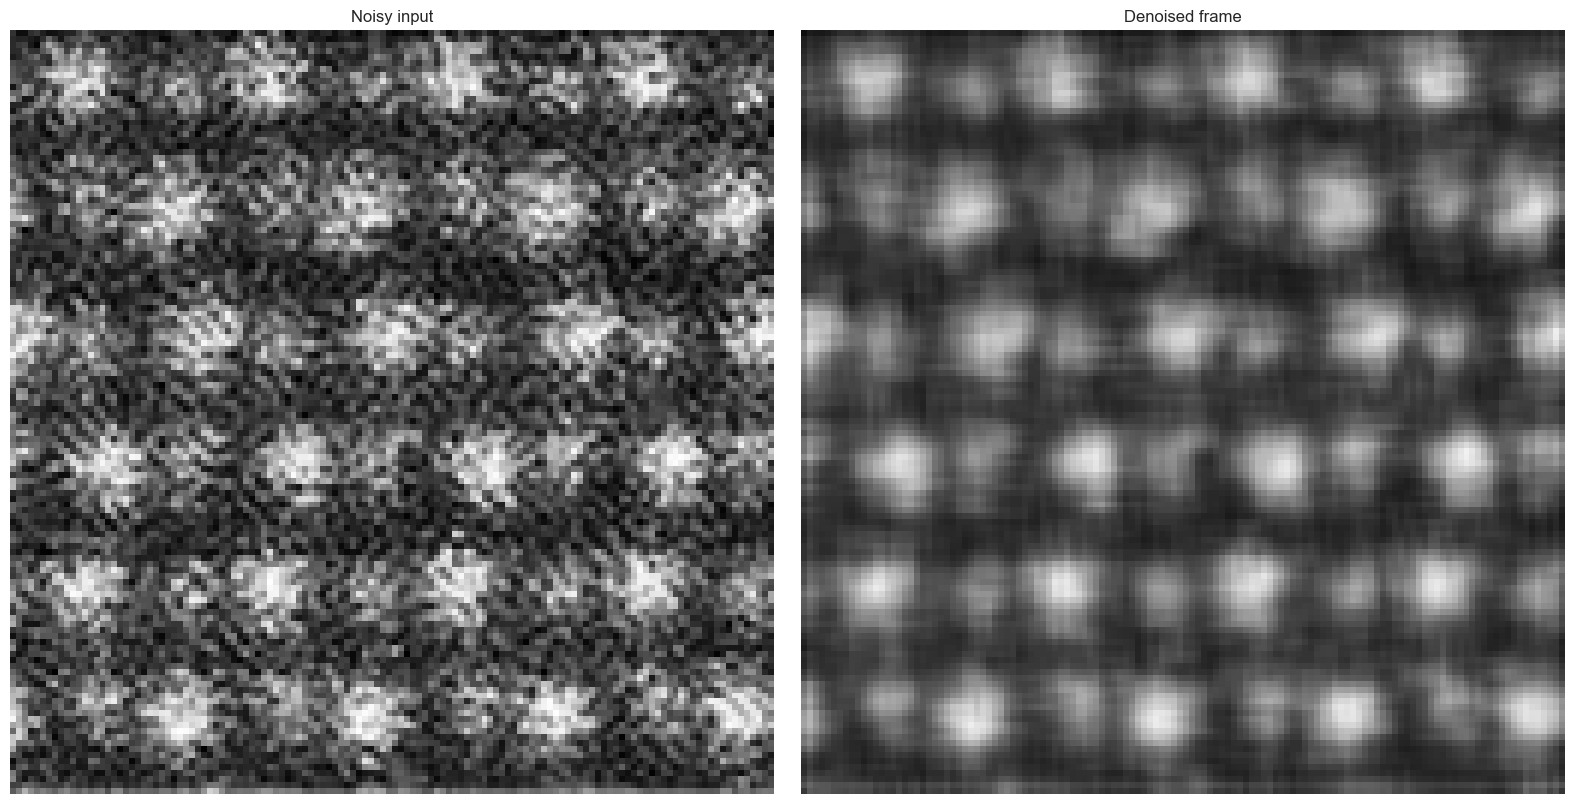

In [35]:
# plot

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16,8))

ax1.imshow(inputs[0,(mid*cpf):((mid+1)*cpf),:,:].cpu().detach().numpy().transpose(1,2,0), cmap="gray", vmin=0, vmax=1) 
ax1.set_title("Noisy input")
ax1.axis("off")

ax2.imshow(outputs[0,:,:,:].cpu().detach().numpy().transpose(1,2,0), cmap="gray", vmin=0, vmax=1) 
ax2.set_title("Denoised frame")
ax2.axis("off")

plt.tight_layout()

# 对整个视频进行去噪

In [36]:
# denoise entire video
patch_size = 128
stride = 128  # 步长

model.eval()

frames = []
save_dir = "../output"
# os.makedirs(os.path.join("../examples", video), exist_ok=True)
# save_dir = os.path.join("../examples", video)


with torch.no_grad():
    for i, noisy_inputs in enumerate(test_loader):
#         # 只处理 i 小于 10 的情况
#         if i >= 10:
#             continue
        
        N, C, H, W = noisy_inputs.shape     
        # 创建一个空的结果图像和权重图来进行平均
        result_image = np.zeros((H,W), dtype=np.float32)
        weight_map = np.zeros((H,W), dtype=np.float32)

        # 遍历图像，使用指定的stride步长
        for y in range(0, H, stride):
            for x in range(0, W, stride):
                # 确定当前patch的右下角坐标
                x_end = x + patch_size
                y_end = y + patch_size
                if x_end > W:
                    x_end = W
                    x = W - patch_size
                if y_end > H:
                    y_end = H
                    y = H - patch_size
#                 print(x,x_end,y,y_end)
                # 提取patch
                patch_inputs = noisy_inputs[:, :, y:y_end, x:x_end].to(device)
#                 print(patch_inputs.shape)
                noisy_frame = patch_inputs[:, 2:3, :, :]
                output, _ = model(patch_inputs)
        
                img = np.array((output[0]/max(1,output[0].max())).cpu().detach().numpy().reshape(w,h)*255, dtype=np.uint8)
                noisy_img = np.array((noisy_frame[0]/max(1,noisy_frame[0].max())).cpu().detach().numpy().reshape(w,h)*255, dtype=np.uint8)
                
                result_image[y:y_end, x:x_end] += img
                weight_map[y:y_end, x:x_end] += 1

#         frame = cv2.cvtColor(np.append(noisy_img, img, axis=1), cv2.COLOR_GRAY2BGR)
#         cv2.line(frame, (W,0), (W,H), (0,0,0), 1)
#         cv2.imwrite(os.path.join(save_dir, "%05d.jpg" % (i)), frame)

        result_image /= np.maximum(weight_map, 1)
        result_image = np.clip(result_image, 0, 255).astype(np.uint8)  # 确保结果在0-255范围内
        
#         # d参数表示邻域直径，sigmaColor表示色彩空间滤波器的sigma，sigmaSpace表示坐标空间滤波器的sigma
#         filtered_image = cv2.bilateralFilter(result_image, d=4, sigmaColor=30, sigmaSpace=30)
        
        frames.append(result_image)

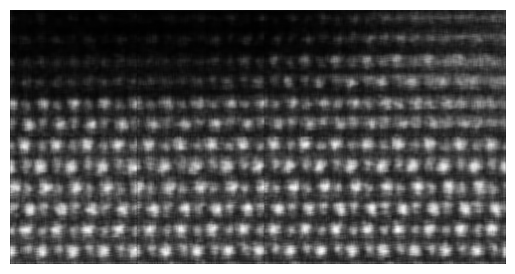

In [37]:
# # 使用matplotlib显示该帧
# # 对整张图像应用双边滤波
# # d参数表示邻域直径，sigmaColor表示色彩空间滤波器的sigma，sigmaSpace表示坐标空间滤波器的sigma
# filtered_image = cv2.bilateralFilter(frames[1], d=6, sigmaColor=50, sigmaSpace=50)

# # # 使用拉普拉斯算子进行锐化
# # laplacian = cv2.Laplacian(filtered_image, cv2.CV_64F)
# # sharp_image = cv2.convertScaleAbs(filtered_image - laplacian)
# plt.imshow(filtered_image, cmap='gray')  # 如果frame是灰度图像，使用 cmap='gray'

plt.imshow(frames[1], cmap='gray')  # 如果frame是灰度图像，使用 cmap='gray'
plt.axis('off')  # 关闭坐标轴
plt.show()

In [38]:
# combining frames into mp4 video
fps = 10

output_file = os.path.join(save_dir, "output_SI.mp4")
height, width = frames[0].shape
out = cv2.VideoWriter(output_file, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
for i in range(len(frames)):
    frame = frames[i]
    # 检查并转换帧为三通道
    if len(frame.shape) == 2:  # 如果是灰度图像
        frame = np.stack((frame,) * 3, axis=-1)  # 手动复制灰度通道
        # 归一化到 [0, 255] 范围
        frame = np.clip(frame, 0, 255)  # 限制在0-255之间
        frame = frame.astype(np.uint8)  # 转换为uint8类型

    cv2.imwrite(f'../output_frame_SI//frame{i}.jpg', frame)
    out.write(frame)
out.release()
print(f'视频已保存为 {output_file}')
# cv2.destroyAllWindows()

视频已保存为 ../output\output_SI.mp4


In [71]:
# # converting mp4 to a gif video (optional)

# from moviepy.editor import *

# video_path = os.path.join(save_dir, f"{video}.mp4")
# gif_path = os.path.join(save_dir, f"{video}.gif")

# clip = (VideoFileClip(video_path).resize(0.5))
# clip.write_gif(gif_path)